<a href="https://colab.research.google.com/github/DhimanTarafdar/handwritten-digit-classification--MNIST-/blob/main/Handwritten_digit_classification_(MNIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1 — Libraries Import**

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# **Step 2 — Random Seed Set**

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)

# **Step 3 — Data Load**

In [3]:
# download and load MNIST train and test data
train_data = datasets.MNIST(root='./data', train=True, download=True,
                             transform=transforms.ToTensor())

test_data = datasets.MNIST(root='./data', train=False, download=True,
                            transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 143MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 37.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 22.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.36MB/s]


# **Step 4 — Data Explore**

Train size: 60000
Test size: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


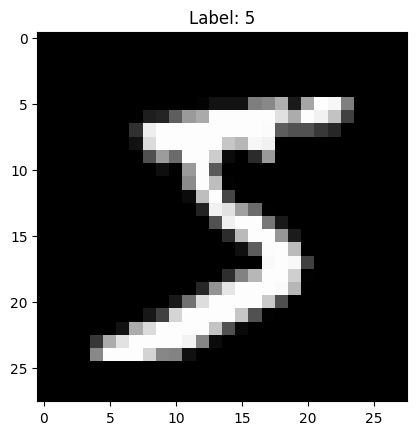

In [4]:
# check shapes
print("Train size:", len(train_data))
print("Test size:", len(test_data))

# show a sample image
image, label = train_data[0]
print("Image shape:", image.shape)
print("Label:", label)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

# **Step 5 — Custom Dataset Class**

In [6]:
# custom dataset class
class CustomDataset(Dataset):

  def __init__(self, data):

    # pixel values flatten and float tensor create
    self.X = torch.stack([item[0].view(-1) for item in data])

    # labels long tensor
    self.y = torch.tensor([item[1] for item in data], dtype=torch.long)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

# **Step 6 — Dataset Object and DataLoader**

In [7]:
# create train and test dataset objects
train_dataset = CustomDataset(train_data)
test_dataset = CustomDataset(test_data)

# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# **Step 7 — Neural Network Class Define**

In [8]:
# define NN class
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

# **Step 8 — Hyperparameters Set**

In [9]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

# **Step 9 — Model, Loss Function and Optimizer**

In [10]:
# instantiate the model
model = MyNN(train_dataset.X.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# **Step 10 — Training Loop**

In [21]:
train_losses = []

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    outputs = model(batch_features)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  train_losses.append(avg_loss)

  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 10 , Loss: 3.5316631673313264e-05
Epoch: 20 , Loss: 3.264962294229446e-05
Epoch: 30 , Loss: 3.030430818512914e-05
Epoch: 40 , Loss: 2.8311787657457426e-05
Epoch: 50 , Loss: 2.653602007894579e-05
Epoch: 60 , Loss: 2.494549542524555e-05
Epoch: 70 , Loss: 2.3546458611120967e-05
Epoch: 80 , Loss: 2.227278628782242e-05
Epoch: 90 , Loss: 2.1114435620646314e-05
Epoch: 100 , Loss: 2.0072688304394858e-05


# **Step 11 — Model to Evaluation Mode**

In [22]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

# **Step 12 — Model Evaluate**

In [23]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct / total)

0.9821


# **Step 13 — A image Predict**

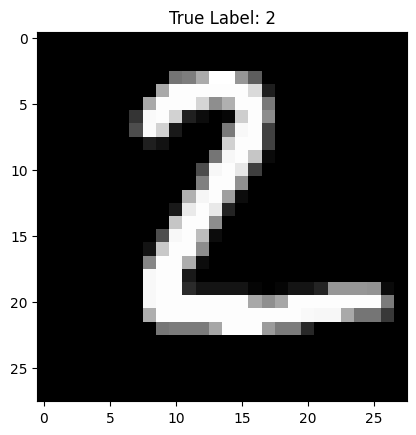

Predicted Label: 2


In [24]:
# predict a single test image
sample_image, true_label = test_data[1]

plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f'True Label: {true_label}')
plt.show()

# reshape and predict
input_tensor = sample_image.view(-1).unsqueeze(0)
predicted_label = model(input_tensor).argmax(axis=1)

print("Predicted Label:", predicted_label.item())

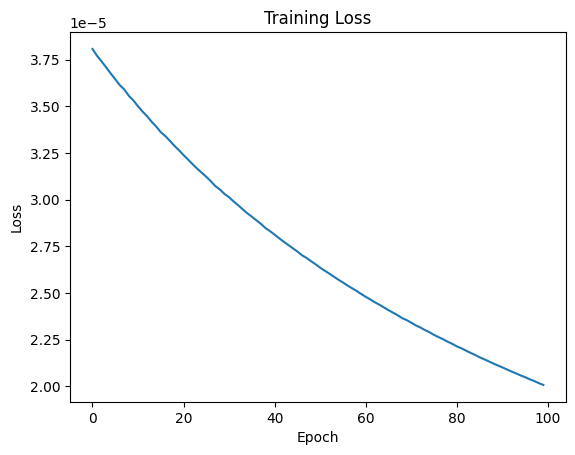

In [25]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()